## 04. FUND PREFORMANCE ANALYTICS

#### Daily Returns


In [1]:
## Computing daily return for all 40 scheme
import pandas as pd
nav=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\02_nav_history_cleaned.csv")

# Computing daily return 
nav['daily_return']=(nav.groupby('amfi_code')['nav'].pct_change())
nav.head(5)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [2]:
nav["daily_return"].isna().sum()

np.int64(40)

In [3]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

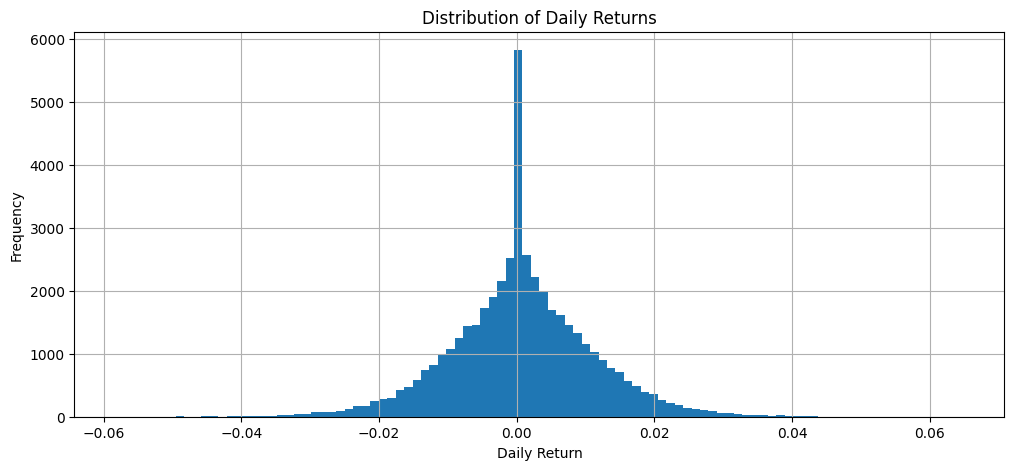

In [4]:
#Disrtibution plot of daily return for all 40 schemes
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
nav['daily_return'].dropna().hist(bins=100)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

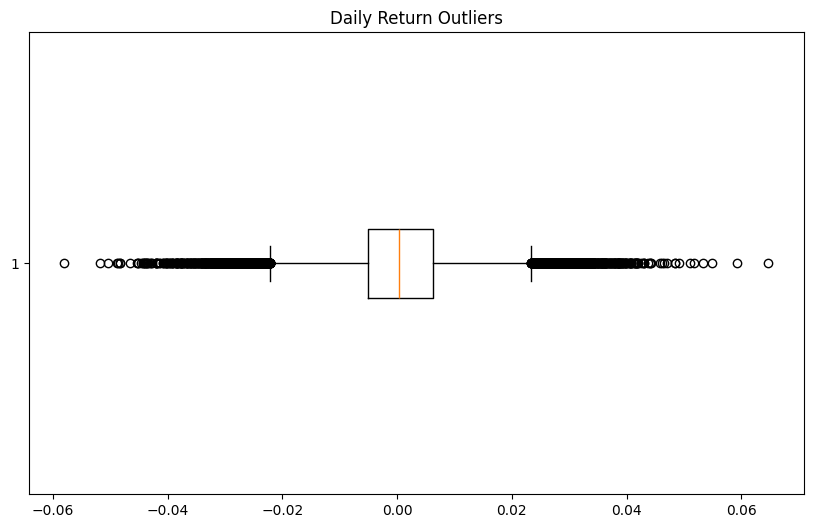

In [5]:
##Box Plot for outline detection
plt.figure(figsize=(10,6))
plt.boxplot(nav['daily_return'].dropna(),vert=False)
plt.title("Daily Return Outliers")
plt.show()  

In [6]:
## Checking extreme returns
nav[(nav['daily_return']>0.30)|
    (nav['daily_return']< -0.30)][["amfi_code","date","nav","daily_return"]]

,amfi_code,date,nav,daily_return


In [7]:
# Return distribution by scheme
scheme_stats = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(["mean","std","min","max"])
       .reset_index()
)

scheme_stats.head()

,amfi_code,mean,std,min,max
0,100016,0.000142,0.009164,-0.024744,0.032145
1,100025,0.000170,0.002460,-0.008188,0.008837
2,100033,0.001080,0.011929,-0.044238,0.041954
3,101206,0.000852,0.009177,-0.038121,0.033956
4,101207,0.000424,0.016251,-0.051847,0.054851


In [8]:
## DATA QUALITY CHECKS
print("Total schemes:", nav["amfi_code"].nunique())
print("Daily return nulls:", nav["daily_return"].isna().sum())
print("Return > 30%:", (nav["daily_return"] > 0.30).sum())
print("Return < -30%:", (nav["daily_return"] < -0.30).sum())

Total schemes: 40
Daily return nulls: 40
Return > 30%: 0
Return < -30%: 0


#### CAGR Report

In [9]:
import pandas as pd 
import numpy as np

#Loading the dataset
nav=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\02_nav_history_cleaned.csv")

#Converting date to datetime
nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

# CAGR calculating function

def calculate_cagr(df, years):
    
    latest_date = df["date"].max()

    start_cutoff = latest_date - pd.DateOffset(years=years)

    # Data within lookback window
    period_df = df[df["date"] >= start_cutoff]

    if len(period_df) < 2:
        return np.nan

    nav_start = period_df.iloc[0]["nav"]
    nav_end = period_df.iloc[-1]["nav"]

    if nav_start <= 0:
        return np.nan

    cagr = (nav_end / nav_start) ** (1 / years) - 1

    return cagr

#Computing CAGR for all 40 schemes/funds
results=[]
 
for amfi_code,group in nav.groupby("amfi_code"):
    results.append(
        {
            "amfi_code":amfi_code,
            "cagr_1y": calculate_cagr(group, 1),
            "cagr_3y": calculate_cagr(group, 3),
            "cagr_5y": calculate_cagr(group, 5)
        }
    )
cagr_df=pd.DataFrame(results)

## Converting to percentage
for col in ["cagr_1y", "cagr_3y", "cagr_5y"]:
    cagr_df[col] = (cagr_df[col] * 100).round(2)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


In [11]:
## Adding Fund name
fund=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\01_fund_master_cleaned.csv")

comparison_table=cagr_df.merge(fund[['amfi_code',"scheme_name"]],
                               on="amfi_code",
                               how="left")

comparison_table=comparison_table[ ["amfi_code", "scheme_name", "cagr_1y", "cagr_3y", "cagr_5y"]]
comparison_table.head(10)

,amfi_code,scheme_name,cagr_1y,cagr_3y,cagr_5y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,2.32
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,3.91
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,6.95
5,101208,ABSL Liquid Fund - Regular - Growth,7.24,6.32,5.71
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,20.21,19.67,15.88
7,102886,UTI Mid Cap Fund - Regular - Growth,-16.80,-0.77,1.03
8,102887,UTI Flexi Cap Fund - Regular - Growth,13.58,25.56,14.68
9,118632,Nippon India Large Cap Fund - Regular - Growth,33.98,22.65,20.88


In [15]:
## Ranking Funds by 5 year CAGR
comparison_table1=comparison_table.sort_values("cagr_5y",ascending=False)

print(comparison_table1.head(10))

# Saving the Comparison Table
comparison_table1.to_csv(
    "D:/bluestock_mf_capstone/data/processed/fund_cagr_comparison1.csv",
    index=False
)

print("Saved: processed/fund_cagr_comparison.csv")

    amfi_code                                        scheme_name  cagr_1y  \
25     120505           ICICI Pru Midcap Fund - Regular - Growth    29.60   
21     119598         SBI Small Cap Fund - Regular Plan - Growth    82.78   
39     149324              DSP Small Cap Fund - Regular - Growth    65.14   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth    39.75   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth    20.36   
30     120843             Kotak Flexicap Fund - Regular - Growth    26.66   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...    53.23   
38     149323                 DSP Midcap Fund - Regular - Growth    21.48   
16     119094                Axis Midcap Fund - Regular - Growth    22.26   
19     119551          SBI Bluechip Fund - Regular Plan - Growth    60.44   

    cagr_3y  cagr_5y  
25    31.78    28.38  
21    26.67    28.03  
39    27.00    27.92  
36    29.18    27.63  
34    34.00    26.80  
30    29.58   

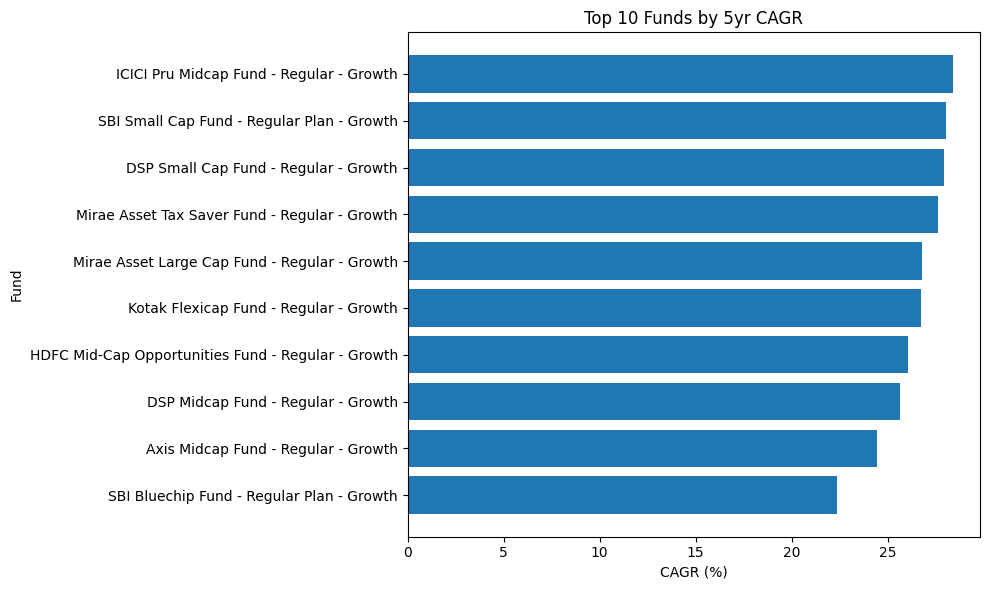

In [16]:
import matplotlib.pyplot as plt

top10 = comparison_table1.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["scheme_name"],
    top10["cagr_5y"]
)

plt.xlabel("CAGR (%)")
plt.ylabel("Fund")
plt.title("Top 10 Funds by 5yr CAGR")

plt.gca().invert_yaxis()  # highest on top

plt.tight_layout()
plt.show()

#### Sharpe Ratio

In [12]:
import pandas as pd 
import numpy as np

#Loading the dataset
nav=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\02_nav_history_cleaned.csv")

#Converting date to datetime
nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

# Computing daily return 
nav['daily_return']=(nav.groupby('amfi_code')['nav'].pct_change())


# Calculating Sharpe Ratio
RF=0.065 #6.5%
RF_Daily=RF/252


results=[]

for fund, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 30:
        continue

    mean_daily = returns.mean()
    std_daily = returns.std()

    sharpe = (
        (mean_daily - RF_Daily)
        / std_daily
    ) * np.sqrt(252)

    results.append({
        "amfi_code": fund,
        "mean_daily_return": mean_daily,
        "daily_volatility": std_daily,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(results)

In [13]:
## Adding Fund/Scheme Name
fund=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\01_fund_master_cleaned.csv")

sharpe_df=sharpe_df.merge(fund[['amfi_code',"scheme_name"]],
                               on="amfi_code",
                               how="left")


# Ranking Funds/Schemes based on Sharpe Ratio
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df["rank"] = range(
    1,
    len(sharpe_df) + 1
)

sharpe_df = sharpe_df[
    [
        "rank",
        "amfi_code",
        "scheme_name",
        "sharpe_ratio"
    ]
]
print(sharpe_df.head(10))

# Saving the ranking
sharpe_df.to_csv(
    r"D:/bluestock_mf_capstone/data/processed/fund_sharpe_ranking.csv",
    index=False
)

print("Saved successfully.")

    rank  amfi_code                                        scheme_name  \
34     1     148567      Mirae Asset Large Cap Fund - Regular - Growth   
30     2     120843             Kotak Flexicap Fund - Regular - Growth   
36     3     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
19     4     119551          SBI Bluechip Fund - Regular Plan - Growth   
25     5     120505           ICICI Pru Midcap Fund - Regular - Growth   
38     6     149323                 DSP Midcap Fund - Regular - Growth   
2      7     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
9      8     118632     Nippon India Large Cap Fund - Regular - Growth   
3      9     101206      ABSL Frontline Equity Fund - Regular - Growth   
24    10     120504          ICICI Pru Bluechip Fund - Direct - Growth   

    sharpe_ratio  
34      1.448291  
30      1.306744  
36      1.234930  
19      1.208267  
25      1.180101  
38      1.132122  
2       1.093699  
9       1.081659  
3       1.0272

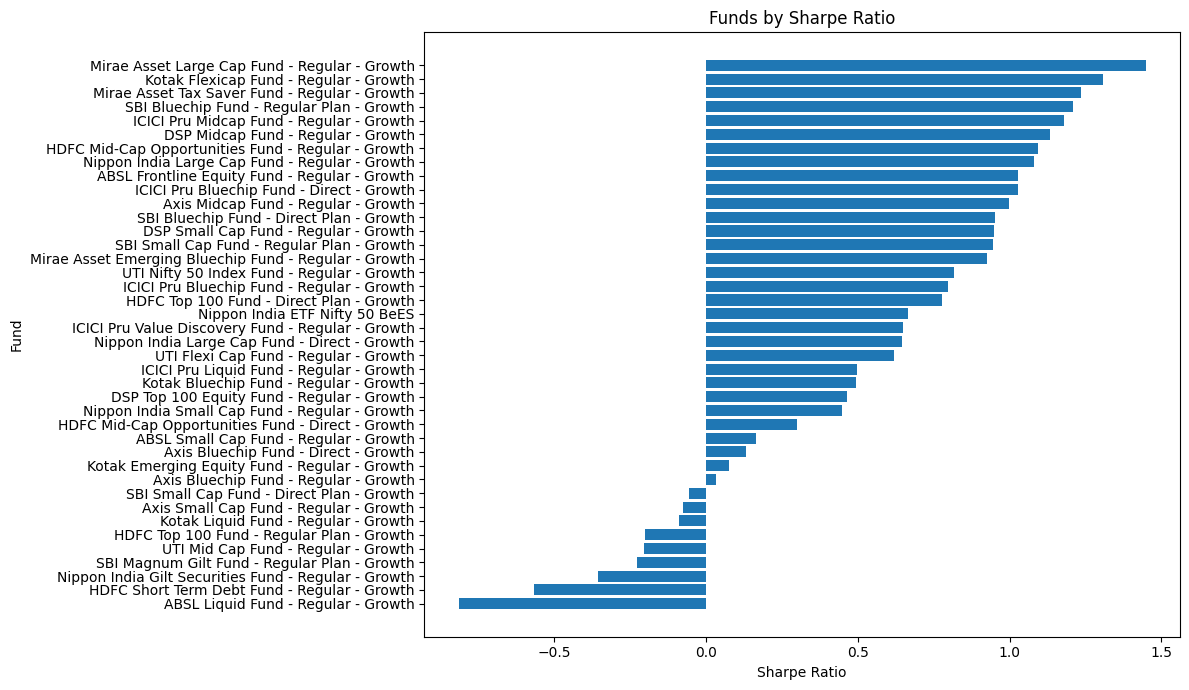

In [14]:
## VISUALIZING TOP  FUNDS/SCHEMES BASED ON SHARPE RATIO
import matplotlib.pyplot as plt

top40 = sharpe_df.head(40)

plt.figure(figsize=(12,7))

plt.barh(
    top40["scheme_name"],
    top40["sharpe_ratio"]
)
plt.title("Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Fund")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show() 

#### Sortino Ratio

In [15]:
import pandas as pd 
import numpy as np

#Loading the dataset
nav=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\02_nav_history_cleaned.csv")

#Converting date to datetime
nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

# Computing daily return 
nav['daily_return']=(nav.groupby('amfi_code')['nav'].pct_change())


# Calculating Sortino Ratio
RF=0.065 #6.5%
RF_Daily=RF/252


results=[]

for fund, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 30:
        continue

    mean_return = returns.mean()

    # Negative-return days only
    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
        sortino = np.nan
    else:
        downside_std = downside_returns.std()

        sortino = (
            (mean_return - RF_Daily)
            / downside_std
        ) * np.sqrt(252)

    results.append({
        "amfi_code": fund,
        "mean_daily_return": mean_return,
        "downside_deviation": downside_std,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(results)



In [16]:
## Merging Fund Names

fund=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\01_fund_master_cleaned.csv")

sortino_df=sortino_df.merge(fund[['amfi_code',"scheme_name"]],
                               on="amfi_code",
                               how="left")

# Ranking Funds/Schemes based on Sortino Ratio
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df["rank"] = range(
    1,
    len(sortino_df) + 1
)

sortino_df = sortino_df[
    [
        "rank",
        "amfi_code",
        "scheme_name",
        "sortino_ratio",
        "downside_deviation"
    ]
]

sortino_df.head(40)

,rank,amfi_code,scheme_name,sortino_ratio,downside_deviation
34,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.385644,0.005428
30,2,120843,Kotak Flexicap Fund - Regular - Growth,2.364320,0.005531
36,3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914,0.006404
19,4,119551,SBI Bluechip Fund - Regular Plan - Growth,2.140267,0.004887
25,5,120505,ICICI Pru Midcap Fund - Regular - Growth,2.029353,0.007067
38,6,149323,DSP Midcap Fund - Regular - Growth,1.875101,0.006750
9,7,118632,Nippon India Large Cap Fund - Regular - Growth,1.850133,0.005211
2,8,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134,0.007133
24,9,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.805294,0.005145
3,10,101206,ABSL Frontline Equity Fund - Regular - Growth,1.799563,0.005238


In [17]:
## Saving the ranking
sortino_df.to_csv(
     r"D:/bluestock_mf_capstone/data/processed/fund_sortino_ranking.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


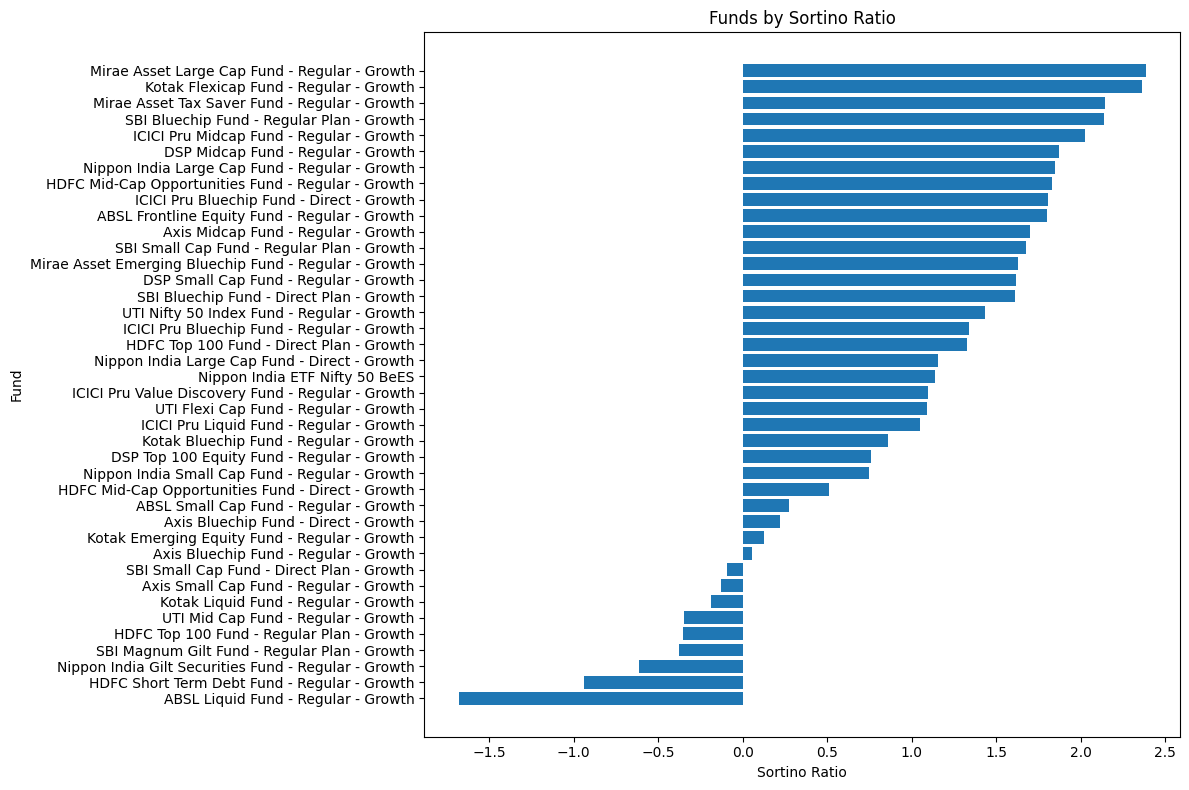

In [18]:
## VISUALIZING  FUNDS/SCHEMES BASED ON SORTINO RATIO
import matplotlib.pyplot as plt

top40 =sortino_df.head(40)

plt.figure(figsize=(12,8))

plt.barh(
    top40["scheme_name"],
    top40["sortino_ratio"]
)
plt.title("Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Fund")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show() 

### Alpha and Beta

In [19]:
# Loading Benchmark dataset

import pandas as pd
import numpy as np
from scipy.stats import linregress

nifty = pd.read_csv(r"D:\bluestock_mf_capstone\data\raw\10_benchmark_indices.csv")

# Conveting date to datetime
nifty["date"] = pd.to_datetime(nifty["date"])

# Sorting the dataset
nifty = nifty.sort_values("date")

#Computing Nifty Return
nifty["nifty_return"] = nifty["close_value"].pct_change()

nifty = nifty[["date", "nifty_return"]]

In [20]:
# Computing Alpha and Beta

results = []

for fund, grp in nav.groupby("amfi_code"):

    merged = grp.merge(
        nifty,
        on="date",
        how="inner"
    )

    merged = merged.dropna(
        subset=["daily_return", "nifty_return"]
    )

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["nifty_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    daily_alpha = regression.intercept

    annual_alpha = daily_alpha * 252

    results.append({
        "amfi_code": fund,
        "alpha": annual_alpha,
        "beta": beta,
        "r_squared": regression.rvalue ** 2,
        "p_value": regression.pvalue
    })

alpha_beta_df = pd.DataFrame(results)

In [21]:
## Adding Funds Names
fund=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\01_fund_master_cleaned.csv")

alpha_beta_df=alpha_beta_df.merge(fund[['amfi_code',"scheme_name"]],
                               on="amfi_code",
                               how="left")

## Ranking by ALPHA
alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

alpha_beta_df["rank"] = range(
    1,
    len(alpha_beta_df) + 1
)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,r_squared,p_value,scheme_name,rank
39,149324,0.296003,0.000008,0.000008,0.804391,DSP Small Cap Fund - Regular - Growth,1
36,148569,0.295861,-0.000022,0.000099,0.373486,Mirae Asset Tax Saver Fund - Regular - Growth,2
21,119598,0.295143,0.000013,0.000017,0.709107,SBI Small Cap Fund - Regular Plan - Growth,3
34,148567,0.278900,-0.000014,0.000067,0.463568,Mirae Asset Large Cap Fund - Regular - Growth,4
25,120505,0.278249,0.000025,0.000108,0.351278,ICICI Pru Midcap Fund - Regular - Growth,5
2,100033,0.265138,0.000012,0.000026,0.645754,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,6
30,120843,0.260693,0.000020,0.000109,0.349357,Kotak Flexicap Fund - Regular - Growth,7
38,149323,0.260204,0.000010,0.000020,0.688224,DSP Midcap Fund - Regular - Growth,8
16,119094,0.254863,0.000007,0.000008,0.803658,Axis Midcap Fund - Regular - Growth,9
19,119551,0.222142,0.000015,0.000081,0.419264,SBI Bluechip Fund - Regular Plan - Growth,10


In [22]:
## Saving the ranking
alpha_beta_df.to_csv(
     r"D:/bluestock_mf_capstone/data/processed/fund_alpha_ranking.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


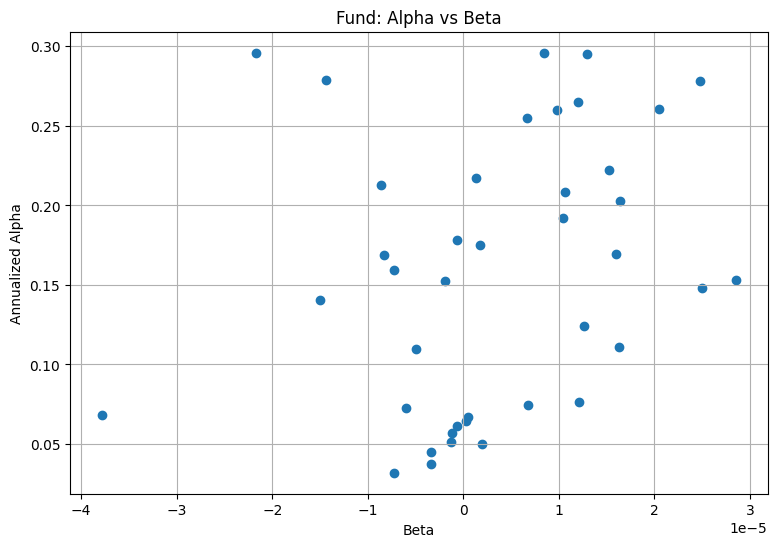

In [23]:
# VISUALIZING: ALPHA VS BETA

import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.scatter(
    alpha_beta_df["beta"],
    alpha_beta_df["alpha"]
)

plt.xlabel("Beta")
plt.ylabel("Annualized Alpha")

plt.title("Fund: Alpha vs Beta")

plt.grid(True)

plt.show()

#### Maximum Drawdown

In [45]:
import pandas as pd 
import numpy as np

#Loading the dataset
nav=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\02_nav_history_cleaned.csv")

#Converting date to datetime
nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

# Sorting the dataset
nav = nav.sort_values("date")

# Finding Worst Drowdown and Date Range
results = []

for fund, grp in nav.groupby("amfi_code"):

    grp = grp.copy()

    # Running peak NAV
    grp["running_max"] = grp["nav"].cummax()

    # Drawdown
    grp["drawdown"] = (
        grp["nav"] / grp["running_max"] - 1
    )

    # Worst drawdown point
    trough_idx = grp["drawdown"].idxmin()

    trough_row = grp.loc[trough_idx]

    max_drawdown = trough_row["drawdown"]

    # Peak date preceding trough
    peak_nav = trough_row["running_max"]

    peak_rows = grp.loc[:trough_idx]

    peak_row = peak_rows[
        peak_rows["nav"] == peak_nav
    ].iloc[0]

    peak_date = peak_row["date"]
    trough_date = trough_row["date"]

    results.append({
        "amfi_code": fund,
        "max_drawdown": max_drawdown,
        "peak_date": peak_date,
        "trough_date": trough_date,
        "peak_nav": peak_row["nav"],
        "trough_nav": trough_row["nav"]
    })

mdd_df = pd.DataFrame(results)

## Converting to percentage
mdd_df["max_drawdown_pct"] = (
    mdd_df["max_drawdown"] * 100
).round(2)

In [46]:
## Adding Funds Names
fund_master=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\01_fund_master_cleaned.csv")

mdd_df=mdd_df.merge(fund_master[['amfi_code',"scheme_name"]],
                               on="amfi_code",
                               how="left")

## Ranking Worst Drawdowns
mdd_df = mdd_df.sort_values(
    "max_drawdown"
)

mdd_df[
    [
        "scheme_name",
        "max_drawdown_pct",
        "peak_date",
        "trough_date"
    ]
].head(40)

,scheme_name,max_drawdown_pct,peak_date,trough_date
22,SBI Small Cap Fund - Direct Plan - Growth,-52.57,2023-01-17,2025-10-28
17,Axis Small Cap Fund - Regular - Growth,-51.68,2025-05-22,2026-05-11
4,ABSL Small Cap Fund - Regular - Growth,-35.45,2024-11-21,2026-05-11
39,DSP Small Cap Fund - Regular - Growth,-31.17,2024-05-03,2025-01-03
21,SBI Small Cap Fund - Regular Plan - Growth,-28.71,2024-08-28,2025-05-14
7,UTI Mid Cap Fund - Regular - Growth,-28.00,2025-01-07,2026-04-27
0,HDFC Top 100 Fund - Regular Plan - Growth,-24.73,2022-03-30,2022-09-15
29,Kotak Emerging Equity Fund - Regular - Growth,-24.00,2023-11-09,2024-10-17
11,Nippon India Small Cap Fund - Regular - Growth,-23.34,2025-04-09,2026-02-20
15,Axis Bluechip Fund - Direct - Growth,-21.75,2022-02-24,2023-05-22


In [47]:
## Saving the ranking
mdd_df.to_csv(
     r"D:/bluestock_mf_capstone/data/processed/mdd_ranking.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


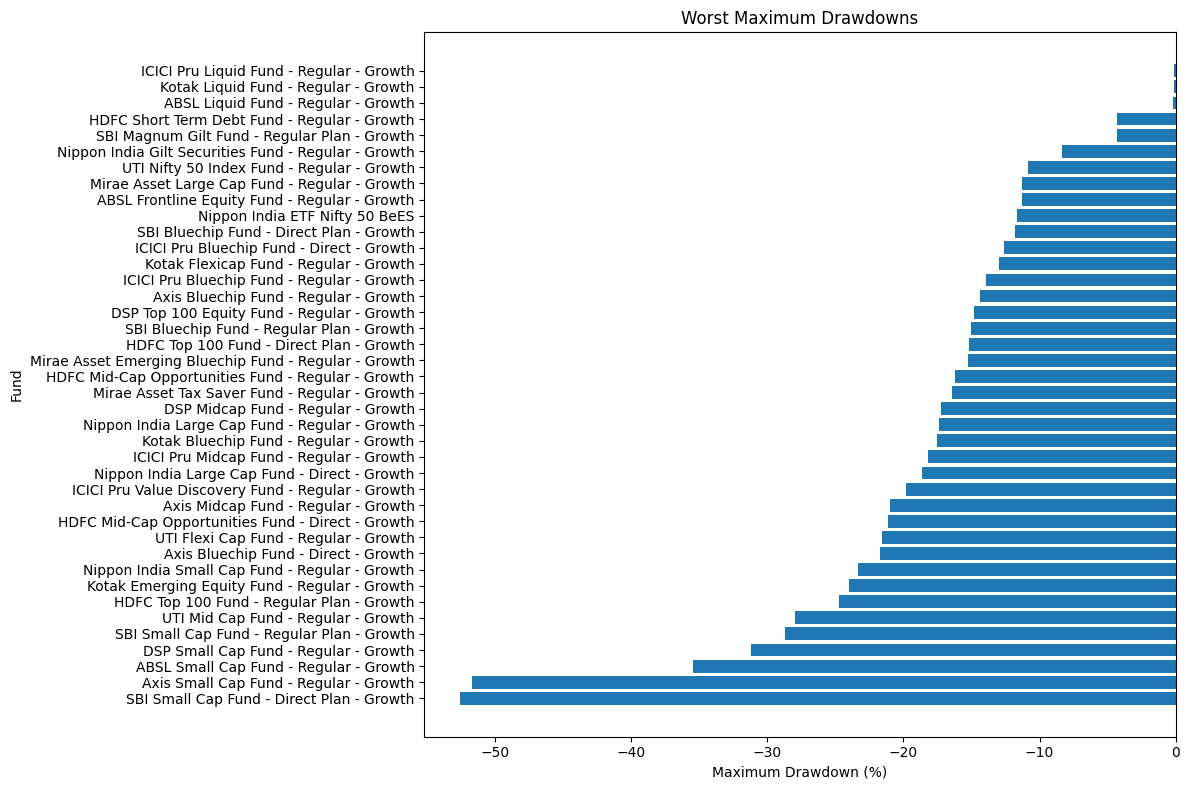

In [27]:
# VISUALIZING WORST MAXIMUM DRAWDOWN
import matplotlib.pyplot as plt

worst = (
    mdd_df
    .sort_values("max_drawdown")
    .head(40)
)

plt.figure(figsize=(12,8))

plt.barh(
    worst["scheme_name"],
    worst["max_drawdown_pct"]
)

plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Fund")
plt.title("Worst Maximum Drawdowns")

plt.tight_layout()
plt.show()

#### Fund Scorecard

In [28]:
# Checking the columns
cagr_df.columns

sharpe_df.columns

alpha_beta_df.columns

mdd_df.columns

fund.columns


Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [29]:
## Merging Everything
scorecard = (
    cagr_df[['amfi_code', 'cagr_3y']]
    .merge(
        sharpe_df[['amfi_code', 'sharpe_ratio']],
        on='amfi_code'
    )
    .merge(
        alpha_beta_df[['amfi_code', 'alpha']],
        on='amfi_code'
    )
    .merge(
        mdd_df[['amfi_code', 'max_drawdown']],
        on='amfi_code'
    )
    .merge(
        fund[
            ['amfi_code',
             'scheme_name',
             'expense_ratio_pct']
        ],
        on='amfi_code'
    )
)


## Creating Ranks for the Scorecard
scorecard["return_rank"] = scorecard[
    "cagr_3y"
].rank(
    ascending=False,
    method="dense"
)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio"
].rank(
    ascending=False,
    method="dense"
)

scorecard["alpha_rank"] = scorecard[
    "alpha"
].rank(
    ascending=False,
    method="dense"
)

In [30]:
## Inverse Ranks
scorecard["expense_rank"] = scorecard[
    "expense_ratio_pct"
].rank(
    ascending=True,
    method="dense"
)

scorecard["mdd_rank"] = scorecard[
    "max_drawdown"
].rank(
    ascending=False,
    method="dense"
)

# Converting Ranks to 0-100 Scores:
n = len(scorecard)

rank_cols = [
    "return_rank",
    "sharpe_rank",
    "alpha_rank",
    "expense_rank",
    "mdd_rank"
]

for col in rank_cols:

    scorecard[col + "_score"] = (
        (n - scorecard[col])
        / (n - 1)
    ) * 100

In [31]:
# Finding Composite Fund Score
scorecard["fund_score"] = (
    0.30 * scorecard["return_rank_score"]

    + 0.25 * scorecard["sharpe_rank_score"]

    + 0.20 * scorecard["alpha_rank_score"]

    + 0.15 * scorecard["expense_rank_score"]

    + 0.10 * scorecard["mdd_rank_score"]
)

scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

# Final Ranking
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard["overall_rank"] = range(
    1,
    len(scorecard) + 1
)

In [32]:
# Final Table
final_scorecard = scorecard[
    [
        "overall_rank",
        "amfi_code",
        "scheme_name",
        "fund_score",
        "cagr_3y",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown"
    ]
]

final_scorecard.head(20)

,overall_rank,amfi_code,scheme_name,fund_score,cagr_3y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
34,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,88.59,34.00,1.448291,0.278900,1.46,-0.112657
30,2,120843,Kotak Flexicap Fund - Regular - Growth,81.67,29.58,1.306744,0.260693,1.45,-0.129740
25,3,120505,ICICI Pru Midcap Fund - Regular - Growth,81.15,31.78,1.180101,0.278249,1.36,-0.181885
2,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,81.03,32.44,1.093699,0.265138,1.38,-0.162172
24,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,79.36,32.49,1.026524,0.202935,0.80,-0.125883
16,6,119094,Axis Midcap Fund - Regular - Growth,77.18,35.11,0.998231,0.254863,1.38,-0.209609
36,7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,76.92,29.18,1.234930,0.295861,1.60,-0.163967
19,8,119551,SBI Bluechip Fund - Regular Plan - Growth,76.67,30.46,1.208267,0.222142,1.54,-0.150124
3,9,101206,ABSL Frontline Equity Fund - Regular - Growth,69.74,28.97,1.027213,0.208464,1.60,-0.112916
38,10,149323,DSP Midcap Fund - Regular - Growth,68.97,26.87,1.132122,0.260204,1.61,-0.172481


In [33]:
## Saving the Fund Scorecard
final_scorecard.to_csv(
    r"D:/bluestock_mf_capstone/data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved.")

Fund Scorecard saved.


### Bechmark Comparison  Chart

In [34]:
## Selecting Top 5 Funds
top5_funds = (
    final_scorecard
    .head(5)["amfi_code"]
    .tolist()
)

print(top5_funds)

# Using yfinance to get  Nifty data
import yfinance as yf

# Nifty 50
nifty50 = yf.download("^NSEI", start="2020-01-01", auto_adjust=True)
nifty50 = nifty50.reset_index()


nifty100 = yf.download(
    "^CNX100",
    start="2020-01-01",
    auto_adjust=True
)

nifty100 = nifty100.reset_index()


nifty50.to_csv("D:/bluestock_mf_capstone/data/raw/nifty50.csv")
nifty100.to_csv("D:/bluestock_mf_capstone/data/raw/nifty100.csv")


[148567, 120843, 120505, 100033, 120504]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [35]:
# Preparing Benchmark Data

nifty50 = pd.read_csv("D:/bluestock_mf_capstone/data/raw/nifty50.csv")
nifty100 = pd.read_csv("D:/bluestock_mf_capstone/data/raw/nifty100.csv")

for df in [nifty50, nifty100]:
    df["Date"] = pd.to_datetime(df["Date"])

nifty50.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in nifty50.columns
]

nifty100.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in nifty100.columns 
]
nifty50["Close"] = pd.to_numeric(
    nifty50["Close"],
    errors="coerce"
)


#Computing Returns
nifty50["return"] = nifty50["Close"].pct_change()

benchmark = nifty50[
    ["Date", "return"]
].rename(
    columns={"Date": "date"}
)

nifty100["Close"] = pd.to_numeric(
    nifty50["Close"],
    errors="coerce")

nifty100["return"] = nifty100["Close"].pct_change()

In [36]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [41]:
## Computing Tracking Error

import numpy as np

tracking_error_results = []

for fund, grp in nav.groupby("amfi_code"):

    merged = grp.merge(
        benchmark,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    active_return = (
        merged["daily_return"]
        -
        merged["return"]
    )

    tracking_error = (
        active_return.std()
        *
        np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": fund,
        "tracking_error": tracking_error
    })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

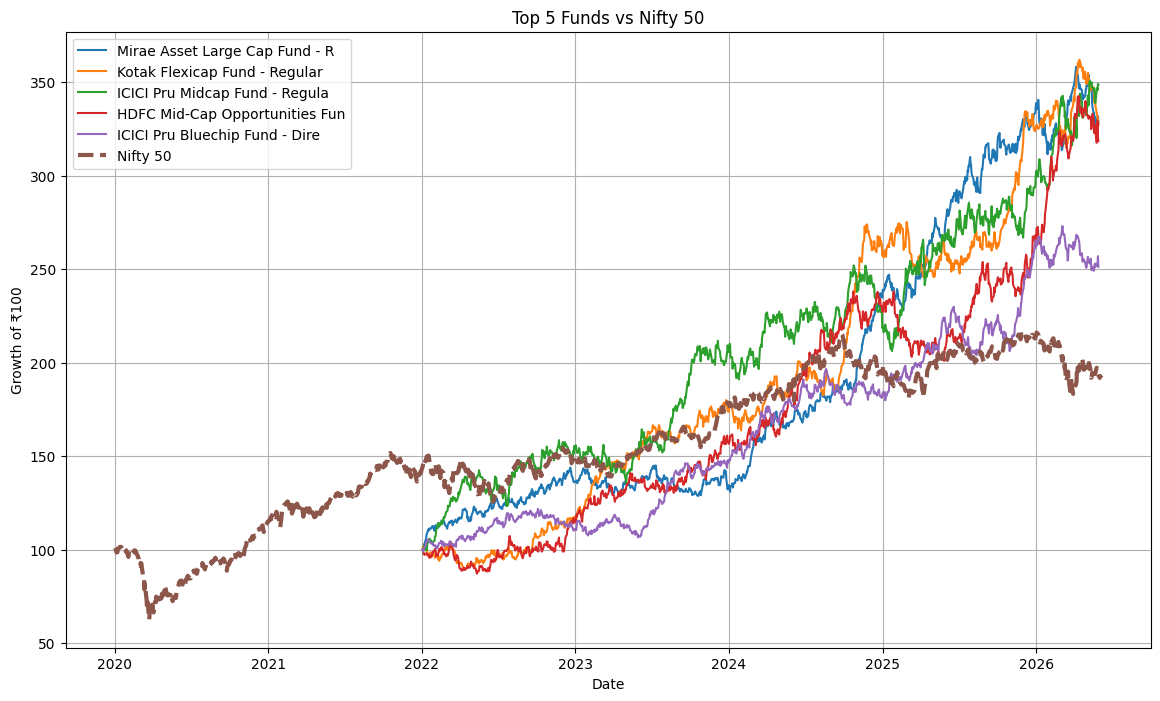

In [48]:
# Takng top 5 funds from Scorecard
top5 = final_scorecard.head(5)

# Creating benchmark growth 
benchmark_growthN50 = benchmark.copy()

benchmark_growthN50["growth"] = (
    (1 + benchmark_growthN50["return"])
    .cumprod()
) * 100

nifty100_growth = nifty100.copy()

nifty100_growth["growth"] = (
    (1 + nifty100_growth["return"])
    .cumprod()
) * 100


## Plotting the benchmark growth

import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for fund in top5["amfi_code"]:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    df = df.sort_values("date")

    start_nav = df["nav"].iloc[0]

    df["growth"] = (
        df["nav"] / start_nav
    ) * 100

    name = (
    fund_master.loc[
        fund_master["amfi_code"] == fund,
        "scheme_name"
    ]
    .iloc[0]
)
    

    plt.plot(
        df["date"],
        df["growth"],
        label=name[:30]
    )

plt.plot(
    benchmark_growthN50["date"],
    benchmark_growthN50["growth"],
    linewidth=3,
    linestyle="--",
    label="Nifty 50"
)

plt.title("Top 5 Funds vs Nifty 50")
plt.ylabel("Growth of ₹100")
plt.xlabel("Date")
plt.legend()
plt.grid(True)

plt.show()



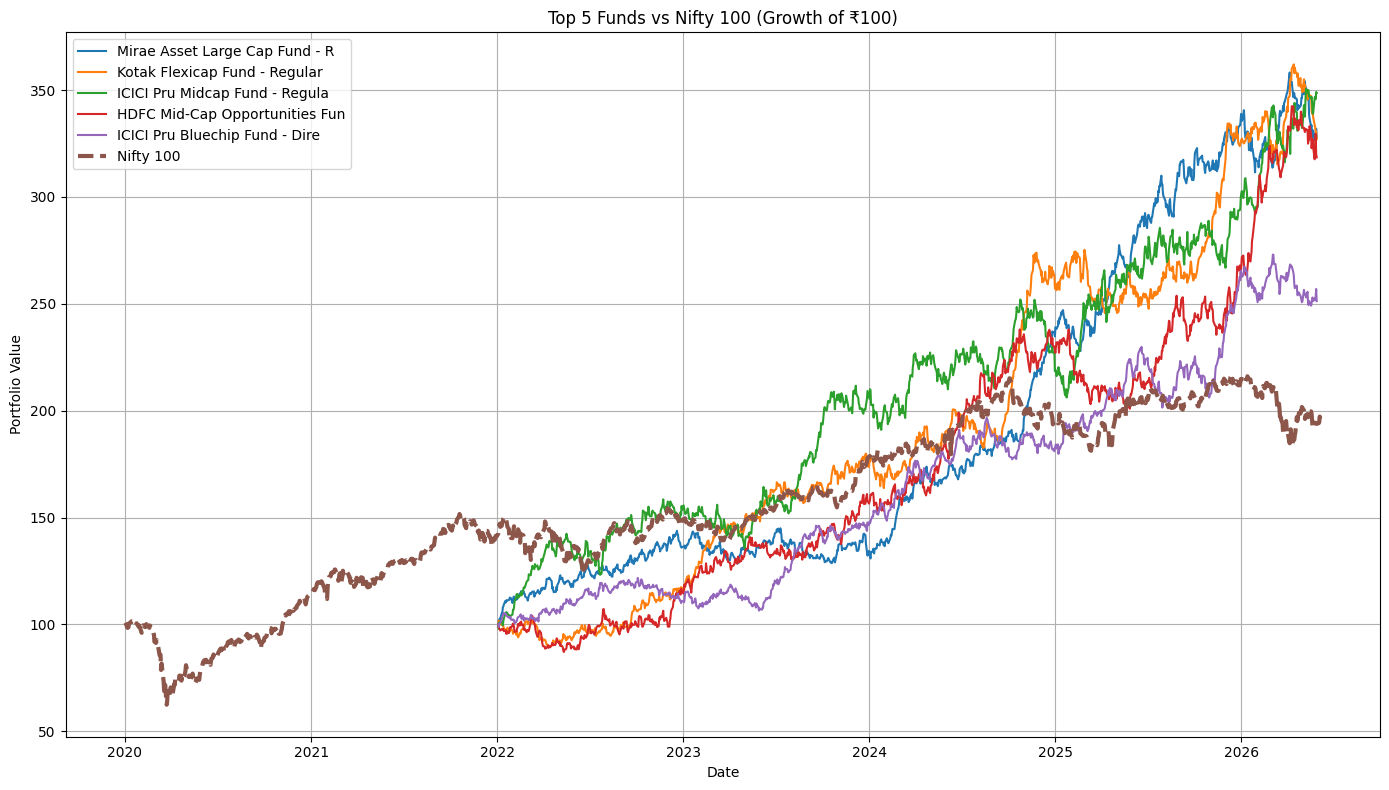

In [50]:
## Plotting for Nifty100
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for fund in top5["amfi_code"]:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    df = df.sort_values("date")

    # Restrict to same date range as Nifty100
    df = df[df["date"] >= nifty100_growth["Date"].min()]

    start_nav = df["nav"].iloc[0]

    df["growth"] = (
        df["nav"] / start_nav
    ) * 100

    scheme_name = (
        fund_master.loc[
            fund_master["amfi_code"] == fund,
            "scheme_name"
        ]
        .iloc[0]
    )

    plt.plot(
        df["date"],
        df["growth"],
        label=scheme_name[:30]
    )

# Nifty 100 benchmark
plt.plot(
    nifty100_growth["Date"],
    nifty100_growth["growth"],
    linewidth=3,
    linestyle="--",
    label="Nifty 100"
)

plt.title("Top 5 Funds vs Nifty 100 (Growth of ₹100)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()